# Intro

In this notebook, we will investigate what learning the generative model of the task could look like. In particular, we will frame learning as inference over possible schedules given observations. First, we will establish theoretical upper bounds on the inference problem from a statistical estimation point of view. Then, we will construct Bayes-optimal posteriors, which can serve as a ground truth when assessing sufficient statistics uncovered by agents trained on the task.

In [147]:
%matplotlib inline

import os
import logging
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import polygamma
from itertools import permutations
import torch
import os

from foraging import SEED
from foraging.utils.autoreload import setup_auto_reload

# Supress annoying warnings and filter out logs that aren't useful here
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# Set up development tools
setup_auto_reload()
pd.options.mode.copy_on_write = True

# from foraging.plotting import bp, format_yticks, per_block, titler
# from foraging.plotting.belief import (
#     plot_accuracy_across_block,
#     plot_cramer_rao_lb,
#     plot_fisher_info,
#     plot_schedule_beliefs_in_block,
#     plot_schedule_beliefs_mean_and_std_across_block,
# )
from foraging.models._base import HashableDict
from foraging.config.experiments import AngelakiPlottingConfig
from foraging.plotting.belief import BeliefPlotter, plot_fisher_info
from foraging.utils.belief import compute_accuracy, compute_schedule_posterior, compute_when_accuracy_threshold_met, compute_joint_schedule_reward_posterior, compute_joint_schedule_reward_posterior_discrete_time
from foraging.utils.belief import fit_policy_to_predict_future_behavior_v2, fit_recent_history_to_predict_future_behavior
from foraging.utils.data import (
    display_df,
    angelaki_exclusion_criteria,
    filter_df,
    make_angelaki_experiment,
    map_box_positions_to_ranks,
)
from foraging.models.distribution import (
    ExactBayesianUpdateOnProbabilities,
    FactorizedPosterior,
    RewardOutcomeLikelihood,
    RewardIntervalLikelihood,
    PermutationLikelihood,
    PossibleSchedules,
    Posterior,
    Probabilities,
)
pd.options.mode.copy_on_write = True

# constants
RNG = np.random.default_rng(SEED)
EXPERIMENT_DIR = "../../data/experiments/angelaki"
# EXPERIMENT_DIR = "../../data/experiments/angelaki/selected_sessions"
ANALYSIS_DIR = "../../data/analysis"

✅ Auto-reload extension already loaded!
✅ Auto-reload w/ 2 mode enabled! Changes to all packages will be automatically loaded.


# Load data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Angelaki Data Cleaning` notebook.

In [148]:
%%capture --no-display
dataset = make_angelaki_experiment(EXPERIMENT_DIR, bin_pushes=1)
dataset = angelaki_exclusion_criteria(dataset, EXPERIMENT_DIR)
dataset = dataset.filter(conds = {"shape": 1})
df = dataset.df
display_df(df, ["subject", "session", "block", "box", "push times", "reward outcomes"])

| subject | session | block | box | push times | reward outcomes |
| --- | --- | --- | --- | --- | --- |
| dylan | 20211206 | 2 | slow | 3.5 | False |
| dylan | 20211206 | 2 | fast | 8.5 | False |
| dylan | 20211206 | 2 | fast | 9.5 | False |
| dylan | 20211206 | 2 | fast | 11.5 | False |
| dylan | 20211206 | 2 | medium | 17.5 | False |

Optimal Fisher info for schedule 15 with shape = 1 occurs at t = 23.9044, with value 0.0029
Optimal Fisher info for schedule 21 with shape = 1 occurs at t = 33.4661, with value 0.0015
Optimal Fisher info for schedule 35 with shape = 1 occurs at t = 55.7768, with value 0.0005


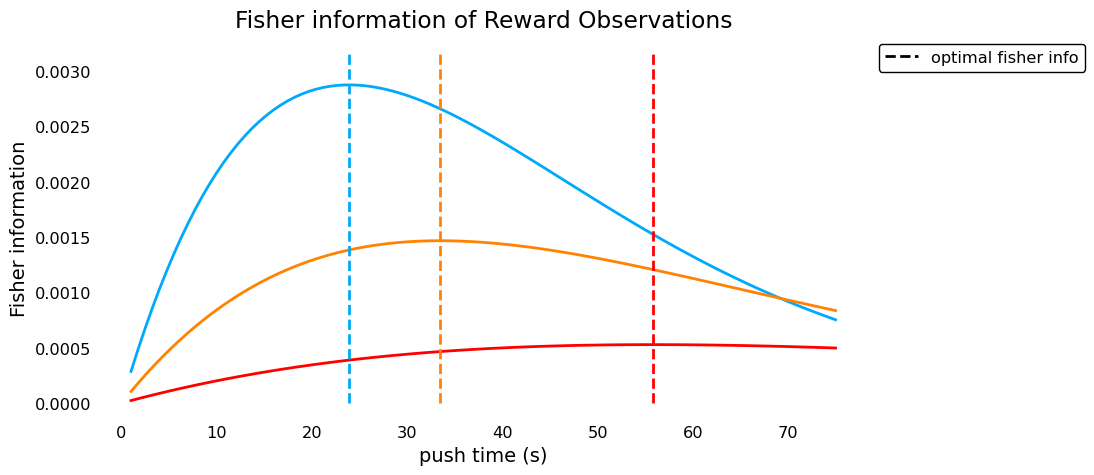

In [3]:
plot_fisher_info(
    np.linspace(1, 75, 100),
    schedules=[15, 21, 35],
    alpha=1,
    title="Fisher information of Reward Observations",
    palette = AngelakiPlottingConfig().PALETTE
);

## Independent Beliefs Over Boxes

Given real behavioral data, we can construct Bayes-optimal beliefs about the schedules using censored observations when the color cue is completely unreliable. These beliefs take the form of a posterior over possible schedules, and they are updated according to Bayes rule:

$$b(\lambda|o_n := t_{\text{push}}) \propto \begin{cases} F(t_{\text{push}} | \lambda)b(\lambda|o_{1:n-1}) & \text{if reward}\\ (1-F(t_{\text{push}} | \lambda))b(\lambda|o_{1:n-1}) &  \text{else}\end{cases}$$

Assuming a uniform prior over possible schedules that resets between blocks, the maximum a posteriori (MAP) estimator is equivalent to the maximum likelihood estimator (MLE). An example posterior over one block is shown below. Inferring the actual prior is an inverse problem that we leave for later analysis.

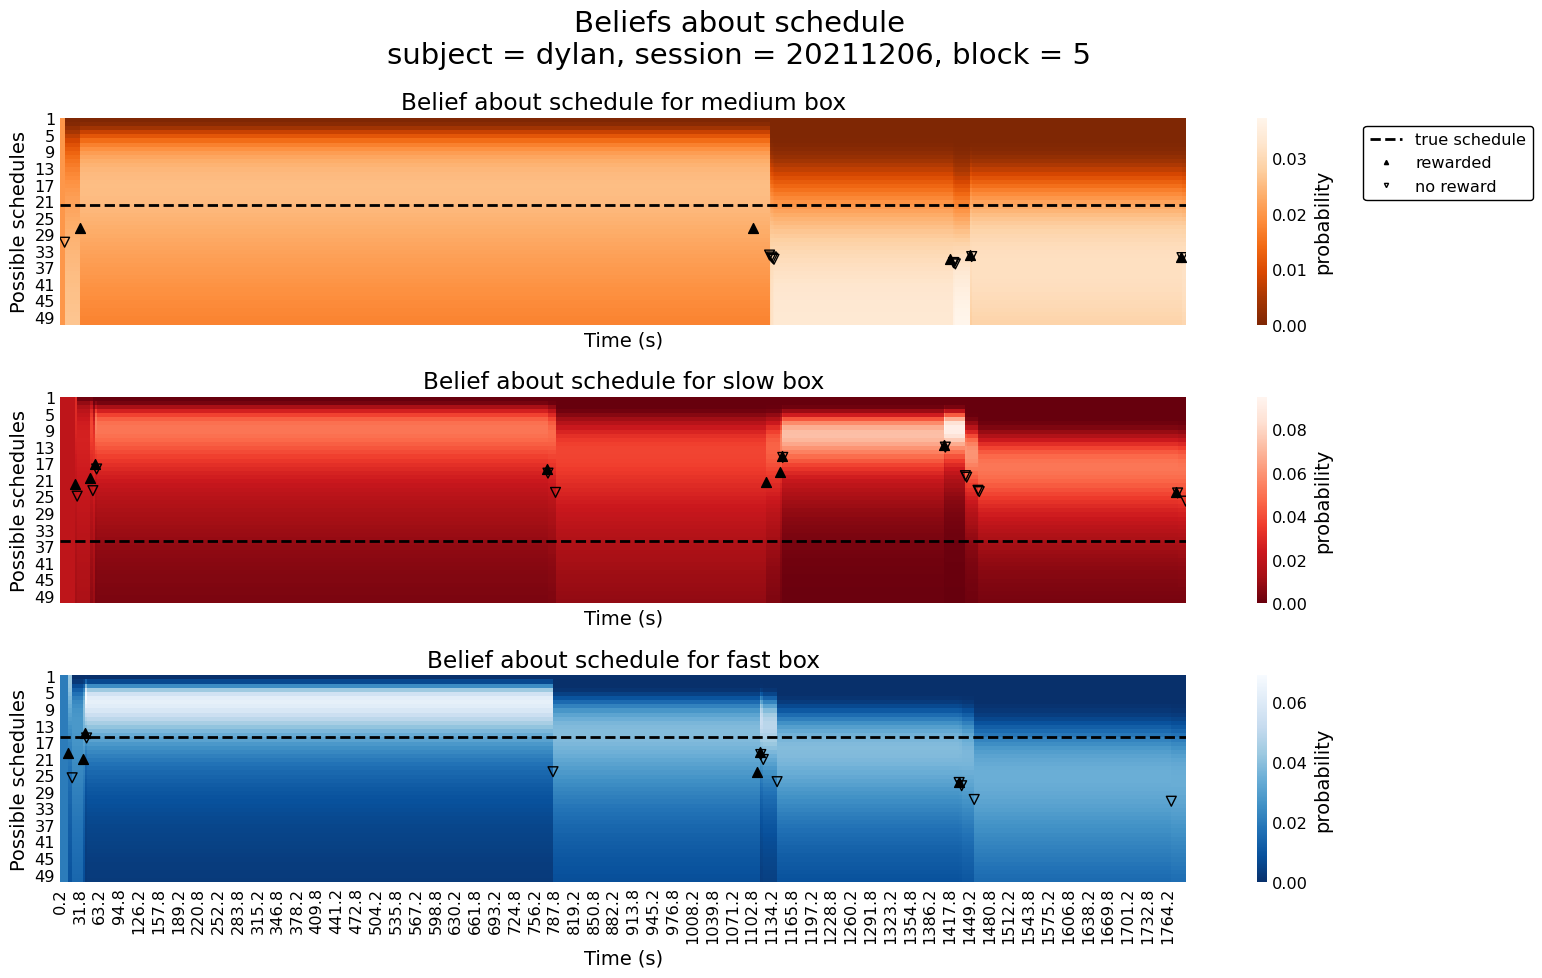

In [ ]:
schedule_candidates = np.arange(50) + 1
belief_update = ExactBayesianUpdateOnProbabilities(RewardOutcomeLikelihood(), vectorize=True)

def posterior_maker(dataset, block_key, block) -> FactorizedPosterior:
    shape = block.index.unique("shape")[0]
    n_boxes = block["n boxes"].values[0]
    uniform = 1 / len(schedule_candidates) * np.ones(len(schedule_candidates))
    single_box_prior = Probabilities(
        support=PossibleSchedules(schedule=schedule_candidates, shape=shape),
        probabilities=uniform,
    )
    return FactorizedPosterior(
        n_boxes, block_key.update("push time", 0), belief_update, prior=single_box_prior
    )

schedule_beliefs, _ = dataset.process_blocks(compute_schedule_posterior, posterior_maker = posterior_maker)
plotter = BeliefPlotter(schedule_beliefs, dataset, AngelakiPlottingConfig().to_dict())
plotter.plot_schedule_beliefs_in_block(conds = dict(subject="viktor", session=20230120, block=4), dt = 0.5);

Now we will aggregate posteriors over blocks and report the average summary statistics of those posteriors.

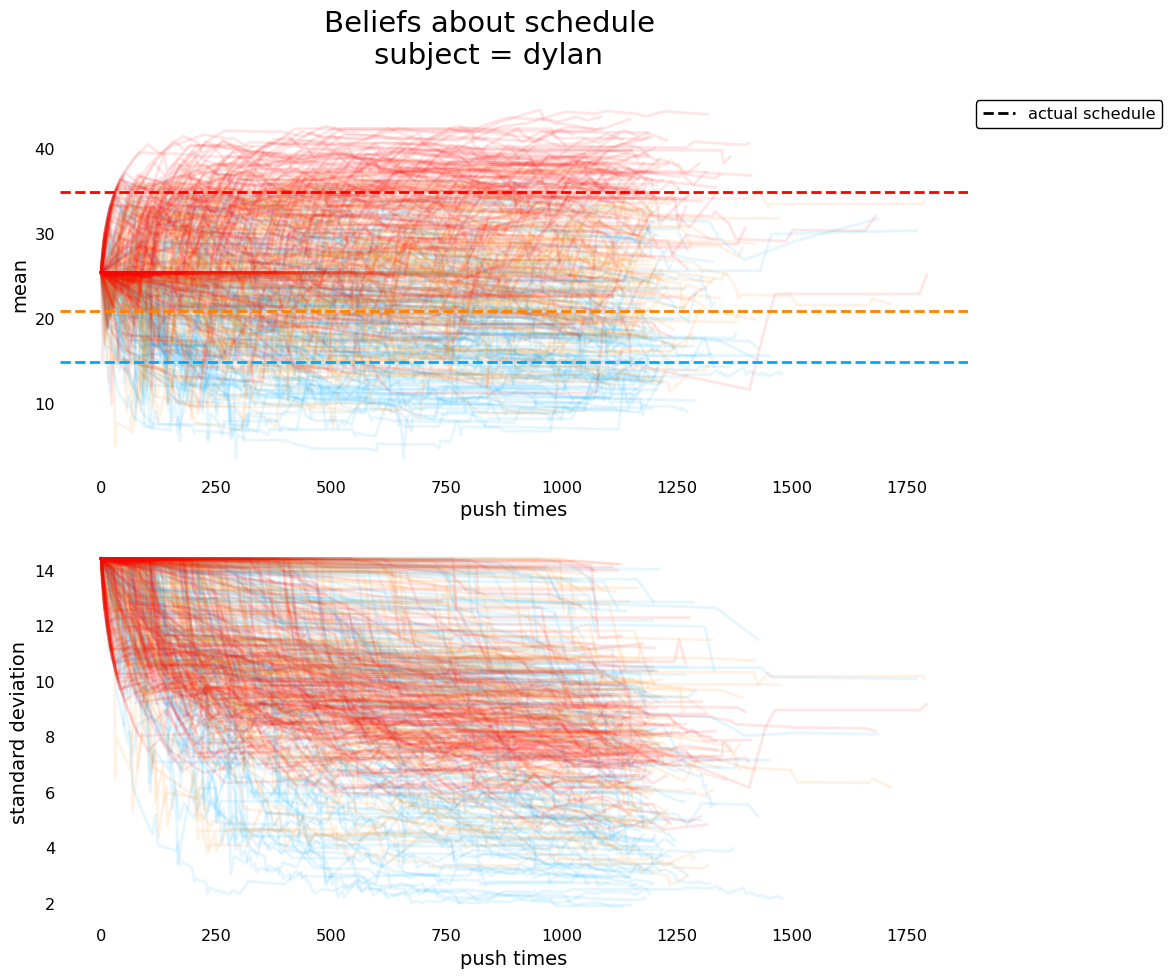

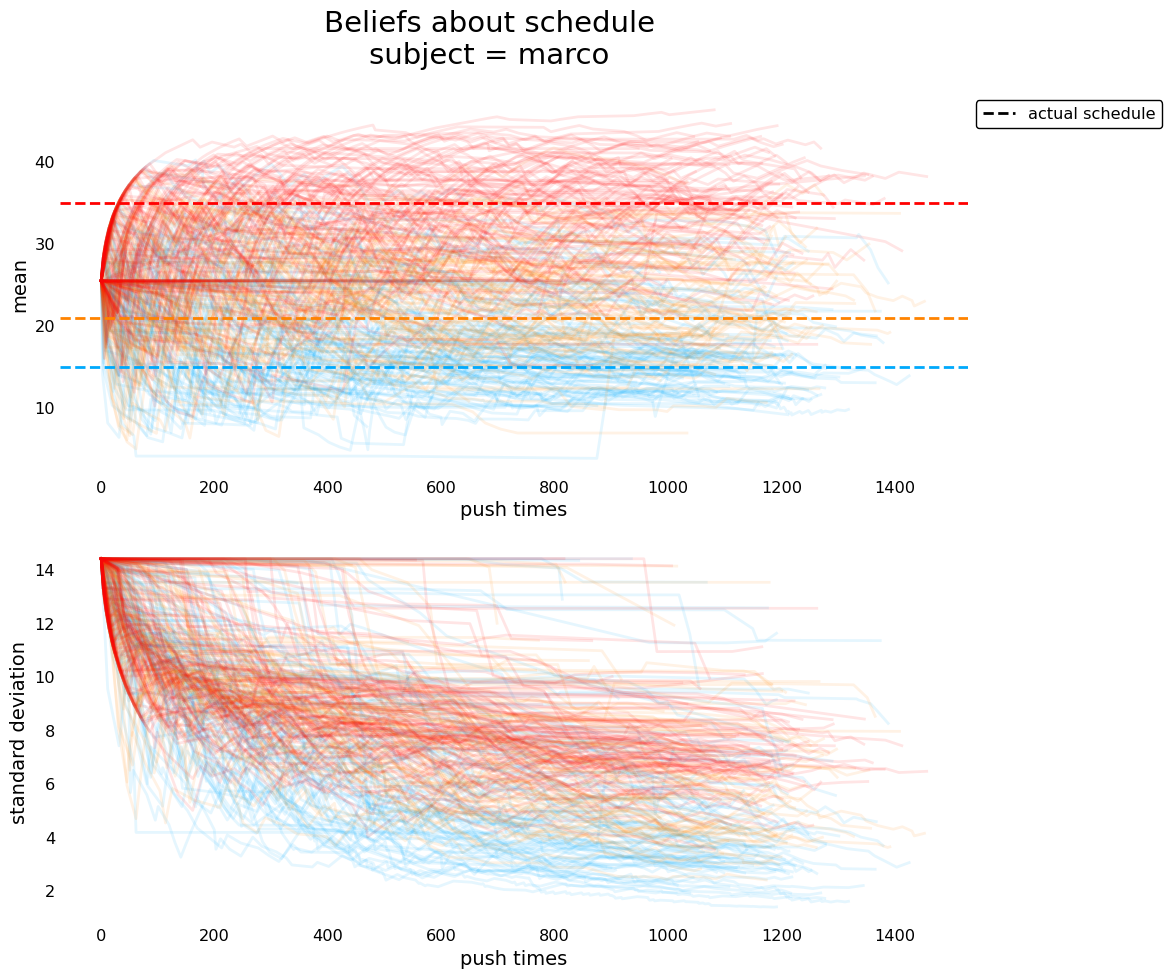

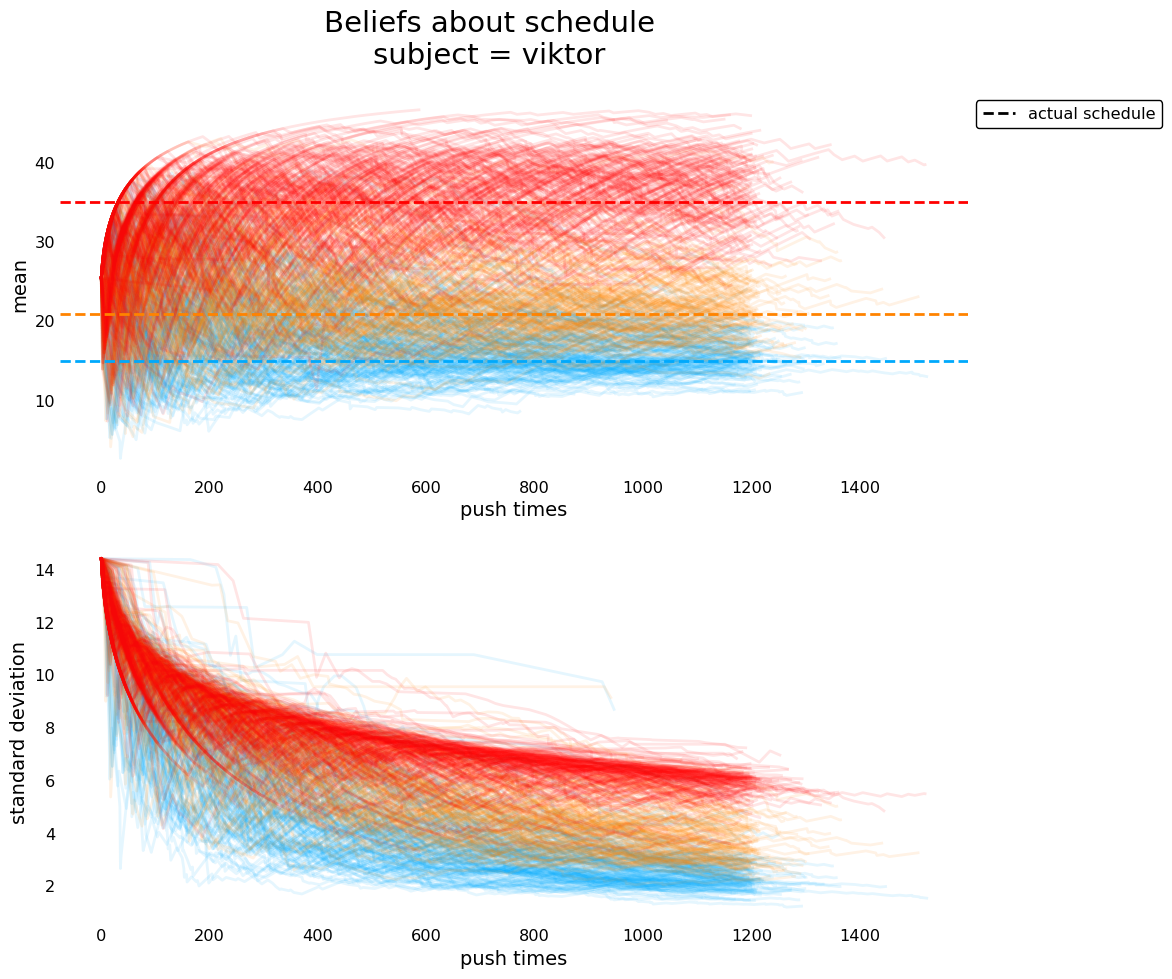

In [5]:
plotter.plot_schedule_beliefs_mean_and_std_across_block(
    x="push times",
    show_traces=True,
    show_average = False
);

## Permutation Beliefs

Now, this framework is only applicable if we assume the subjects 1) treat the boxes as independent and 2) start their inference process from scratch at the start of each block. If the schedules are kept constant over several blocks and merely permuted, then it is conceivable that the subjects eventually get a good handle on the identities of the schedules and only infer the assighment of specific schedules to boxes, not the values of the schedules themselves. In that case, their beliefs are defined over $m!$ permutations, where $m$ is the number of boxes. Analogous to the Fisher information, one can simulate observations under one of the permutations and show how quickly the posterior converges to the right permutation as a function of the number of observations (the result will generalize to the other permutations).

With respect to box ordering, the permutation and continuous beliefs from before carry the same amount of information (in fact, the continuous beliefs can converge to the permutation beliefs via Monte Carlo). Obviously, when it comes the values of the schedules themselves, the permutations don't carry that information since this knowledge is assumed, and that the only knowledge missing is the assignment of schedules to box positions.

<Axes: title={'center': 'Belief about permutation'}, xlabel='Time (s)', ylabel='Possible permutations'>

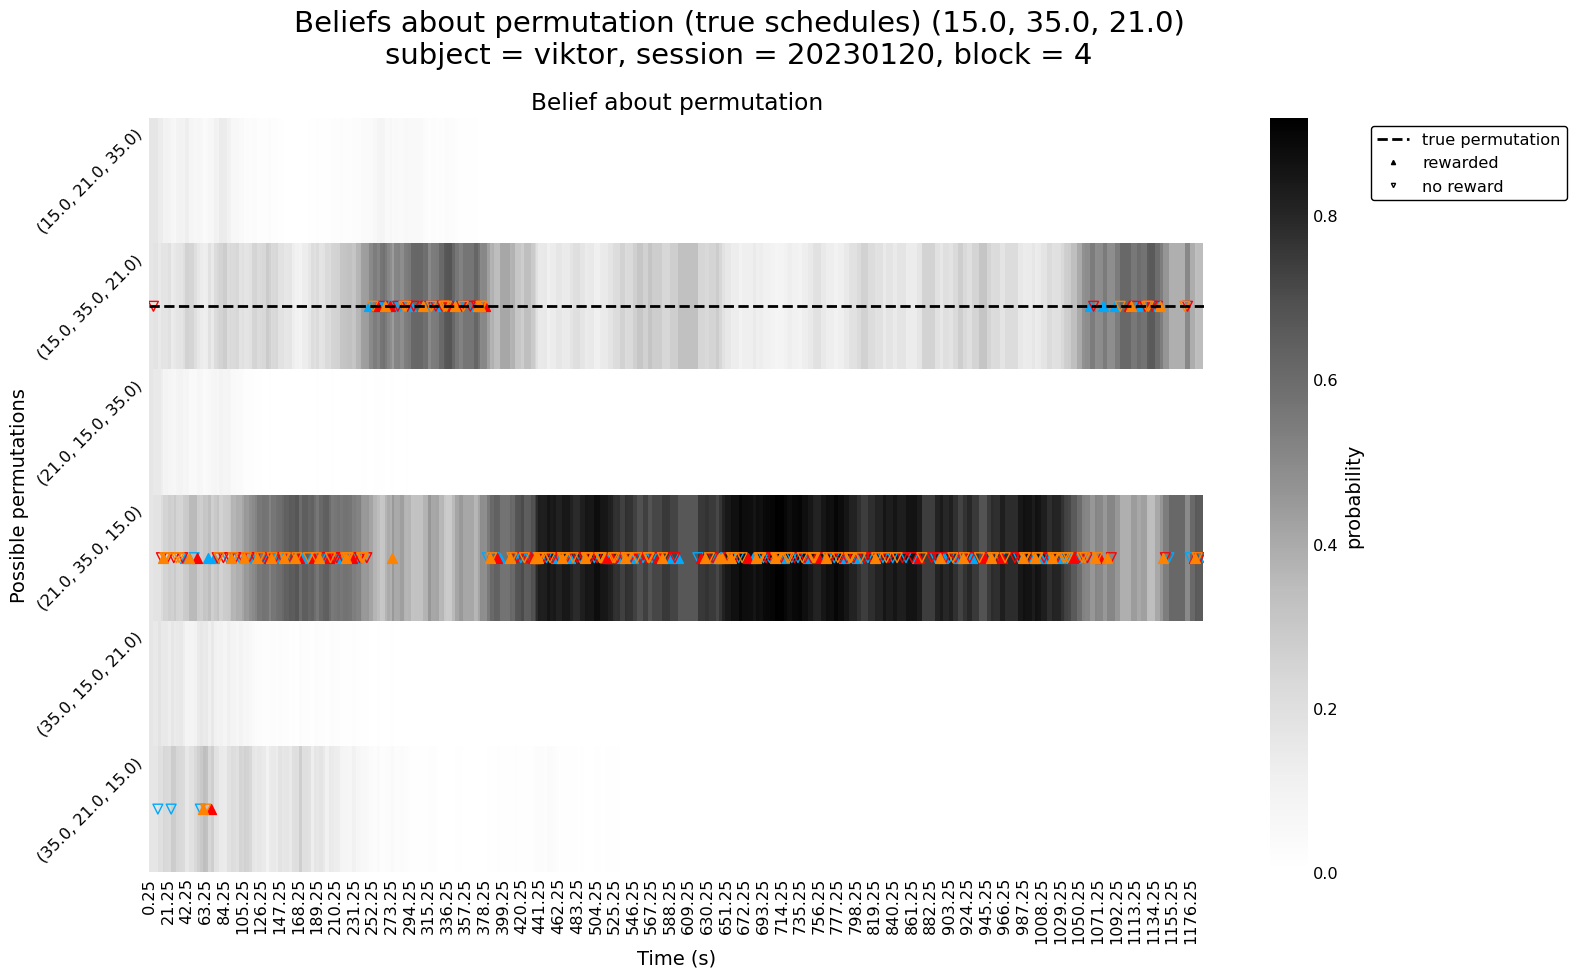

In [3]:
from foraging.models.distribution import Permutation2SchedulesWrapper

_belief_update = ExactBayesianUpdateOnProbabilities(PermutationLikelihood())
def belief_update(x, y):
    p = _belief_update(x, y)
    return Permutation2SchedulesWrapper(p.support, p.representation)

def posterior_maker(dataset, block_key, block) -> Posterior:
    block = block.reset_index()
    shape = block["shape"].iloc[0]
    schedules = sorted(block["assigned schedules"].iloc[0])
    perms = list(permutations(schedules))
    uniform = 1 / len(perms) * np.ones(len(perms))
    prior = Permutation2SchedulesWrapper(
        support= [PossibleSchedules(schedule = x, shape = shape) for x in perms],
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return Posterior(
        new_key, update = belief_update, prior=prior
    )

perm_beliefs, _ = dataset.process_blocks(compute_schedule_posterior, posterior_maker = posterior_maker)
plotter = BeliefPlotter(perm_beliefs, dataset, AngelakiPlottingConfig().to_dict())
plotter.plot_permutation_beliefs_in_block(conds = dict(subject="viktor", session=20230120, block=4), dt = 0.5)

## Accuracy

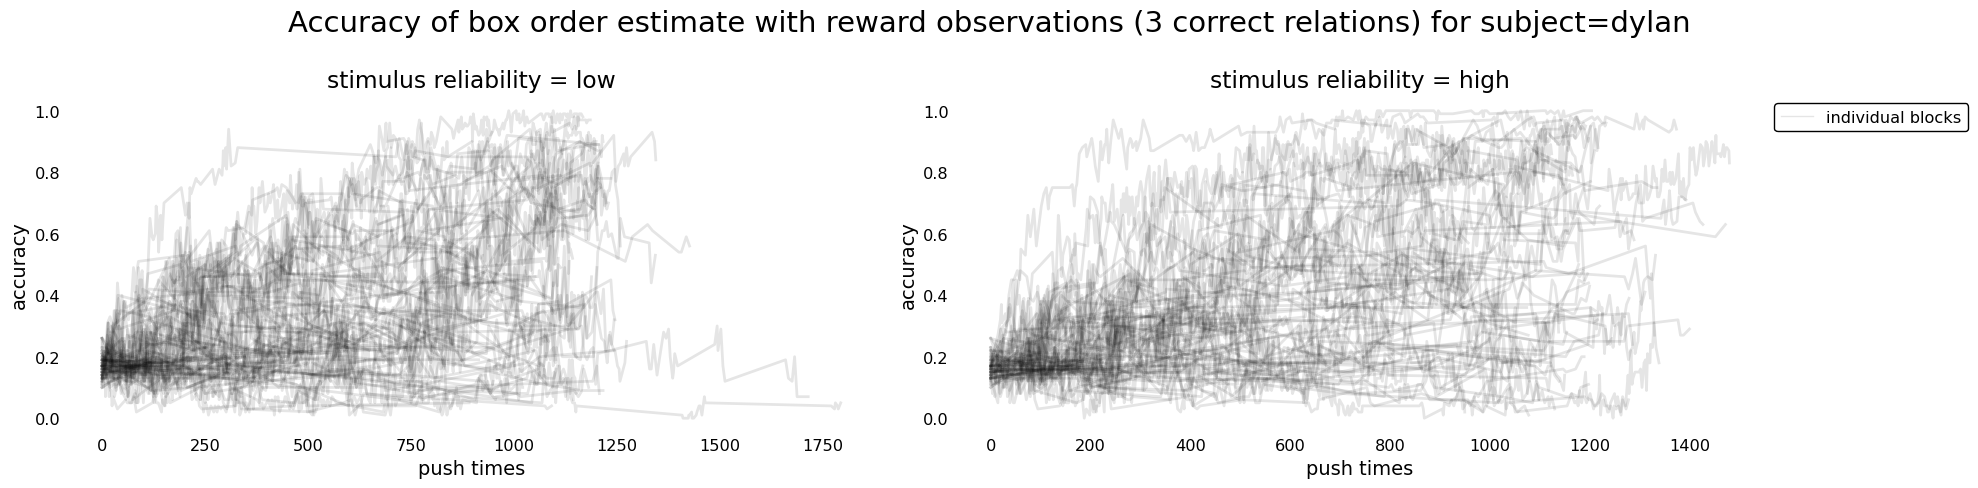

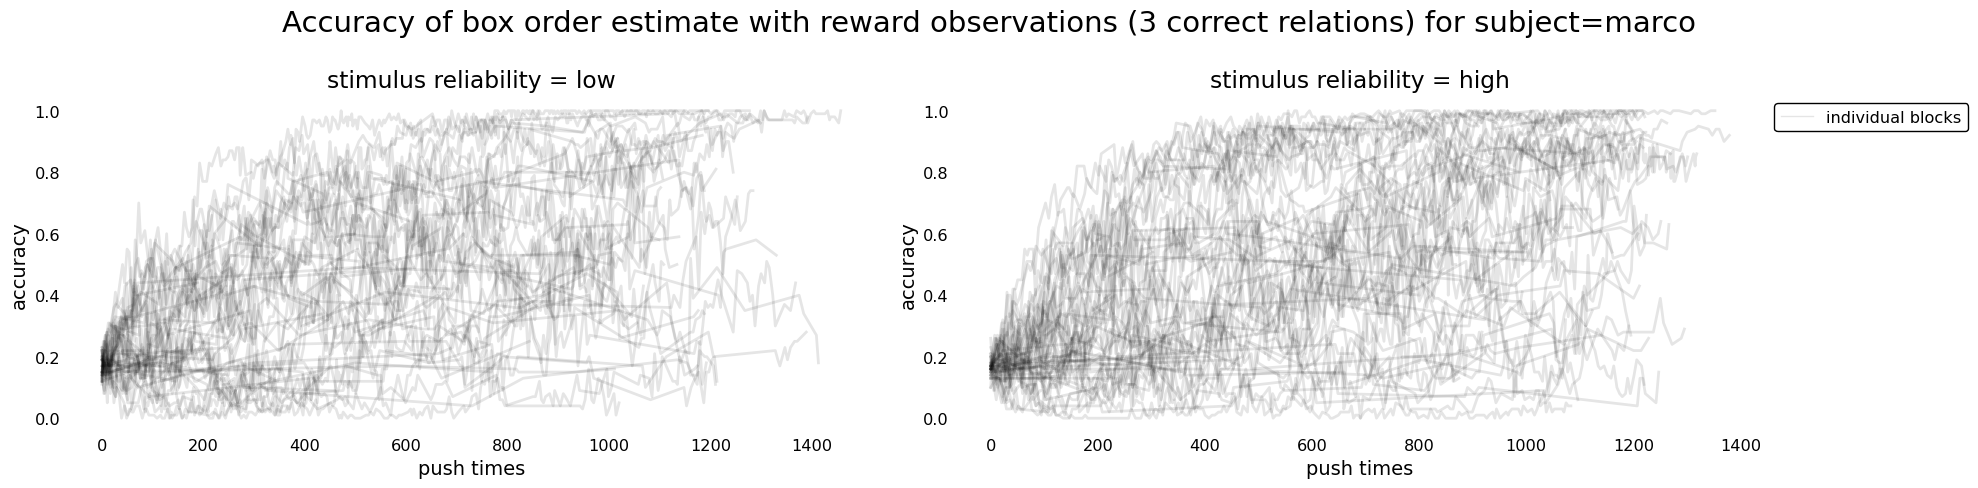

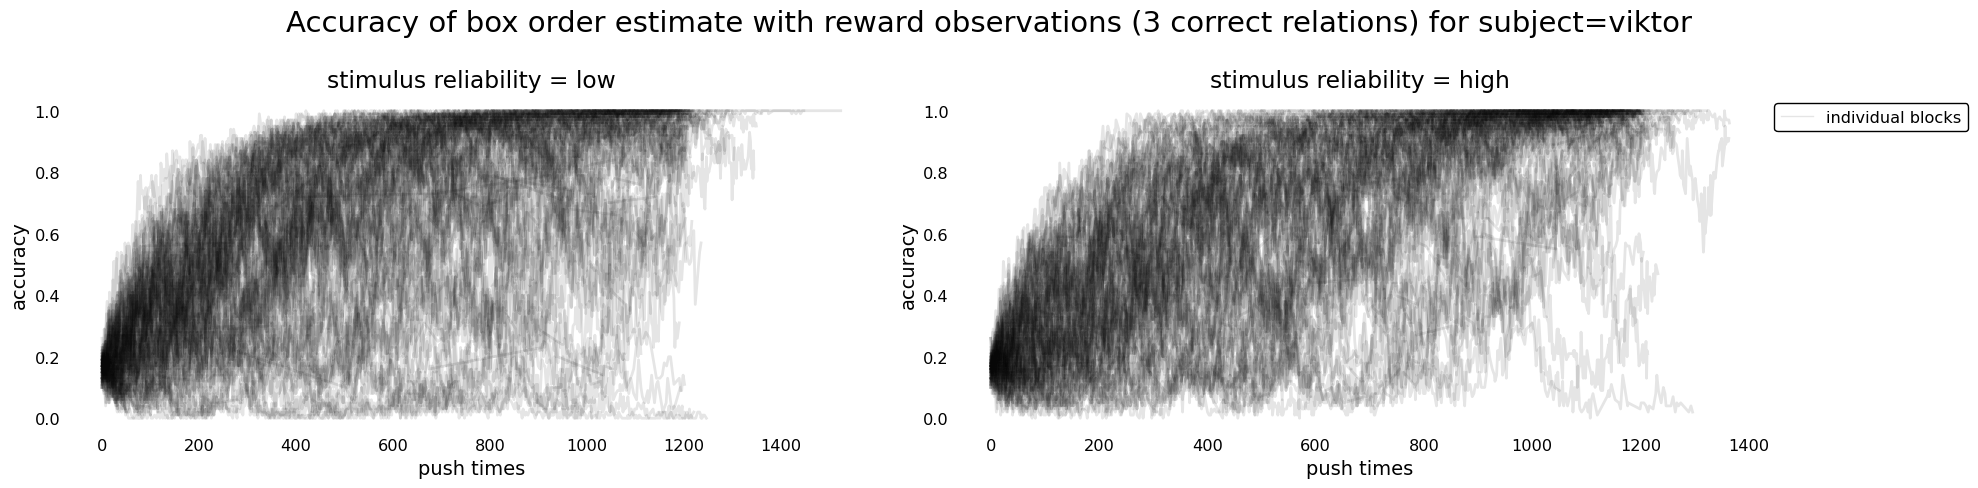

In [12]:
n_correct = 3
accuracies, _ = dataset.process_blocks(compute_accuracy, beliefs = perm_beliefs, n_correct = n_correct, n_samples = 100)
plotter.plot_conditions_by_subject(
    plotter.plot_accuracy_across_block, 
    accuracies = accuracies,
    col_condition = 'stimulus reliability',
    x="push times",
    show_traces=True,
    show_average = False,
    color="black",       
    fig_title=f'Accuracy of box order estimate with reward observations ({n_correct} correct relations)' 
);

In [8]:
#TODO: illustrate blocks where the accuracy is low for n_correct = 3 but high for n_correct < 3
accuracies_3, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = 3, n_samples = 500)
accuracies_2, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = 2, n_samples = 500)
accuracies_1, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = 1, n_samples = 500)

In [9]:
import numpy as np

# accuracies: dict[HashableDict (or tuple), ArrayLike]
worst_key, worst_max = [None]*15, np.array([np.inf]*15)

for key, acc in accuracies_3.items():
    if key['subject'] != 'viktor':
        continue

    stim_reliability = dataset.filter(key).get_unique("stimulus reliability")[0]
    if stim_reliability != "high":
        continue

    acc = np.asarray(acc, dtype=float)
    # m = np.nanmax(acc)  # use max(acc) if you know there are no NaNs
    m = acc[-1]
    w = np.argmax(worst_max)
    if m < worst_max[w]:
        worst_max[w] = m
        worst_key[w] = key

print("block with lowest max accuracy:", worst_key)
print("that block's max accuracy:", worst_max)

block with lowest max accuracy: [{'subject': 'viktor', 'session': np.int64(20230215), 'block': np.int64(4)}, {'subject': 'viktor', 'session': np.int64(20230214), 'block': np.int64(4)}, {'subject': 'viktor', 'session': np.int64(20221117), 'block': np.int64(5)}, {'subject': 'viktor', 'session': np.int64(20230127), 'block': np.int64(1)}, {'subject': 'viktor', 'session': np.int64(20221101), 'block': np.int64(2)}, {'subject': 'viktor', 'session': np.int64(20221019), 'block': np.int64(4)}, {'subject': 'viktor', 'session': np.int64(20221021), 'block': np.int64(7)}, {'subject': 'viktor', 'session': np.int64(20221021), 'block': np.int64(8)}, {'subject': 'viktor', 'session': np.int64(20221018), 'block': np.int64(1)}, {'subject': 'viktor', 'session': np.int64(20230120), 'block': np.int64(5)}, {'subject': 'viktor', 'session': np.int64(20221013), 'block': np.int64(3)}, {'subject': 'viktor', 'session': np.int64(20221026), 'block': np.int64(4)}, {'subject': 'viktor', 'session': np.int64(20221025), 'b

{'subject': 'viktor', 'session': np.int64(20230215), 'block': np.int64(4)}


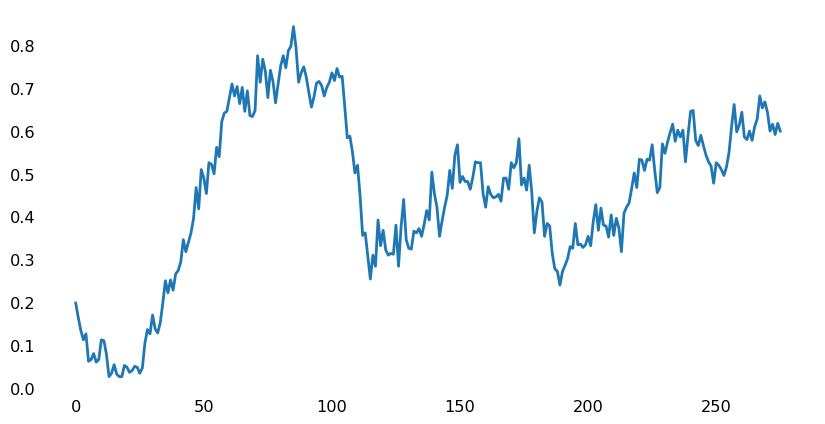

In [10]:
plt.plot(accuracies_3[worst_key[0]])
print(worst_key[0])

{'subject': 'viktor', 'session': np.int64(20230215), 'block': np.int64(4)}


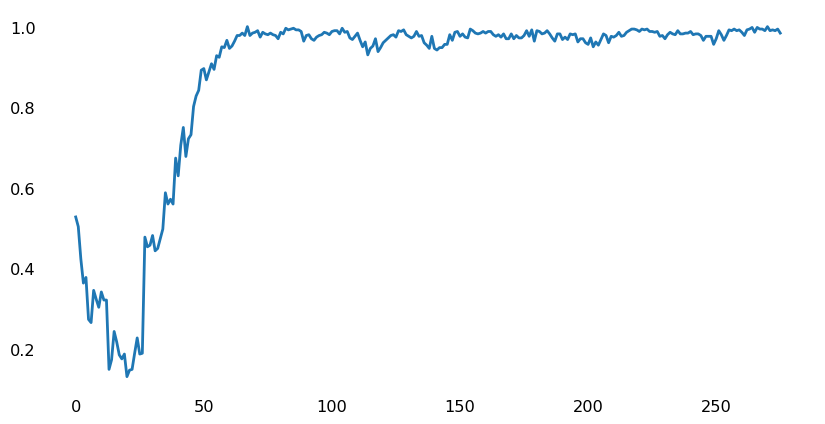

In [11]:
plt.plot(accuracies_2[worst_key[0]])
print(worst_key[0])

Count how many correct order relations for each box by end of block

In [12]:
from foraging.utils.belief import compute_per_box_accuracy
accuracies, _ = dataset.process_blocks(compute_per_box_accuracy, beliefs = schedule_beliefs, n_correct = 3, n_samples = 500)

In [13]:
# look at beliefs at the end of the block
t_cut = 700
vals = defaultdict(list)
for k, v in accuracies.items():
    time = v["time"]
    if time[-1] < t_cut:
        continue   
    vals[k["subject"]].append(v["correct_counts"][time > t_cut])

vals_viktor = np.vstack(vals["viktor"])
vals_marco = np.vstack(vals["marco"])
vals_dylan = np.vstack(vals["dylan"])

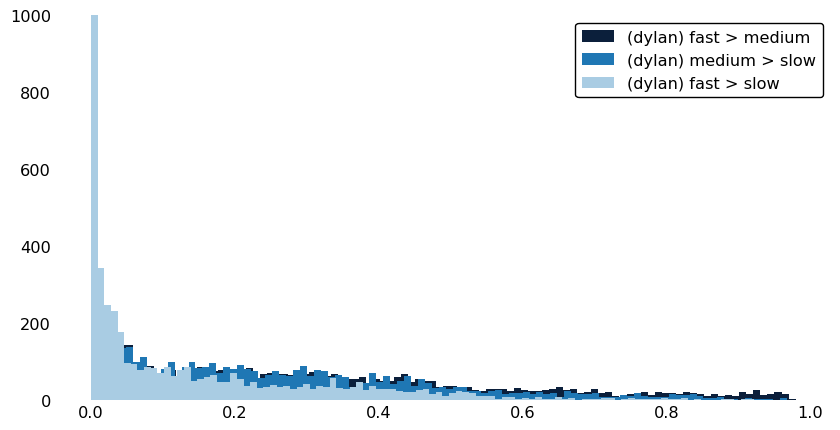

In [14]:
# plt.hist(vals_viktor[:,1,0], label = "(viktor) fast > medium", bins = 100, color = '#A7D7A9')
# plt.hist(vals_viktor[:,2,1], label = "(viktor) medium > slow", bins = 100, color = '#2E8B57')
# plt.hist(vals_viktor[:,2,0], label = "(viktor) fast > slow", bins = 100, color = '#0B3D2E')

# plt.hist(vals_marco[:,1,0], label = "(marco) fast > medium", bins = 100, color = '#F5CBA7')
# plt.hist(vals_marco[:,2,1], label = "(marco) medium > slow", bins = 100, color = '#E67E22')
# plt.hist(vals_marco[:,2,0], label = "(marco) fast > slow", bins = 100, color = '#7A2E00')

plt.hist(vals_dylan[:,1,0], label = "(dylan) fast > medium", bins = 100, color = '#0B1F3B')
plt.hist(vals_dylan[:,2,1], label = "(dylan) medium > slow", bins = 100, color = '#1F77B4')
plt.hist(vals_dylan[:,2,0], label = "(dylan) fast > slow", bins = 100, color = '#A9CCE3')

# plt.hist(vals_all[:,1,2]/500, label = "medium > slow")
# plt.xlim(0.8, 1)
plt.ylim(0, 1000)
plt.legend()

when do they figure it out in the block?

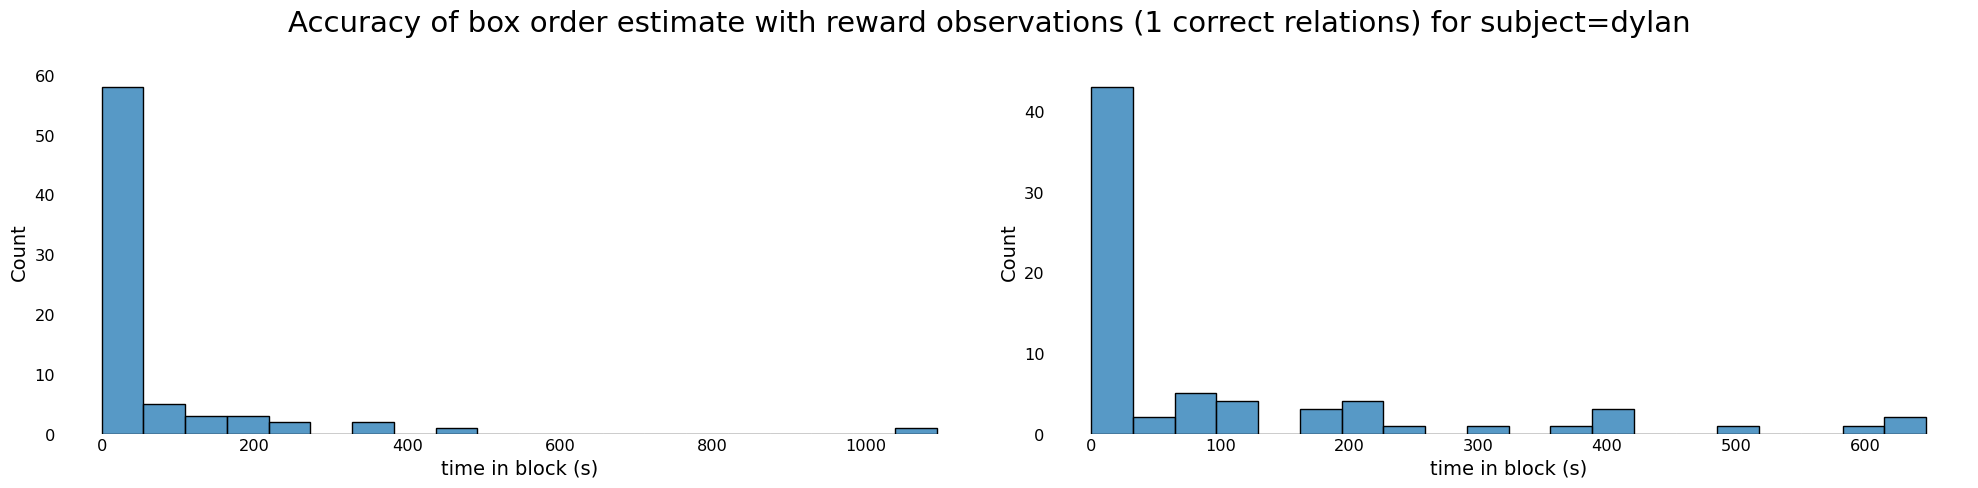

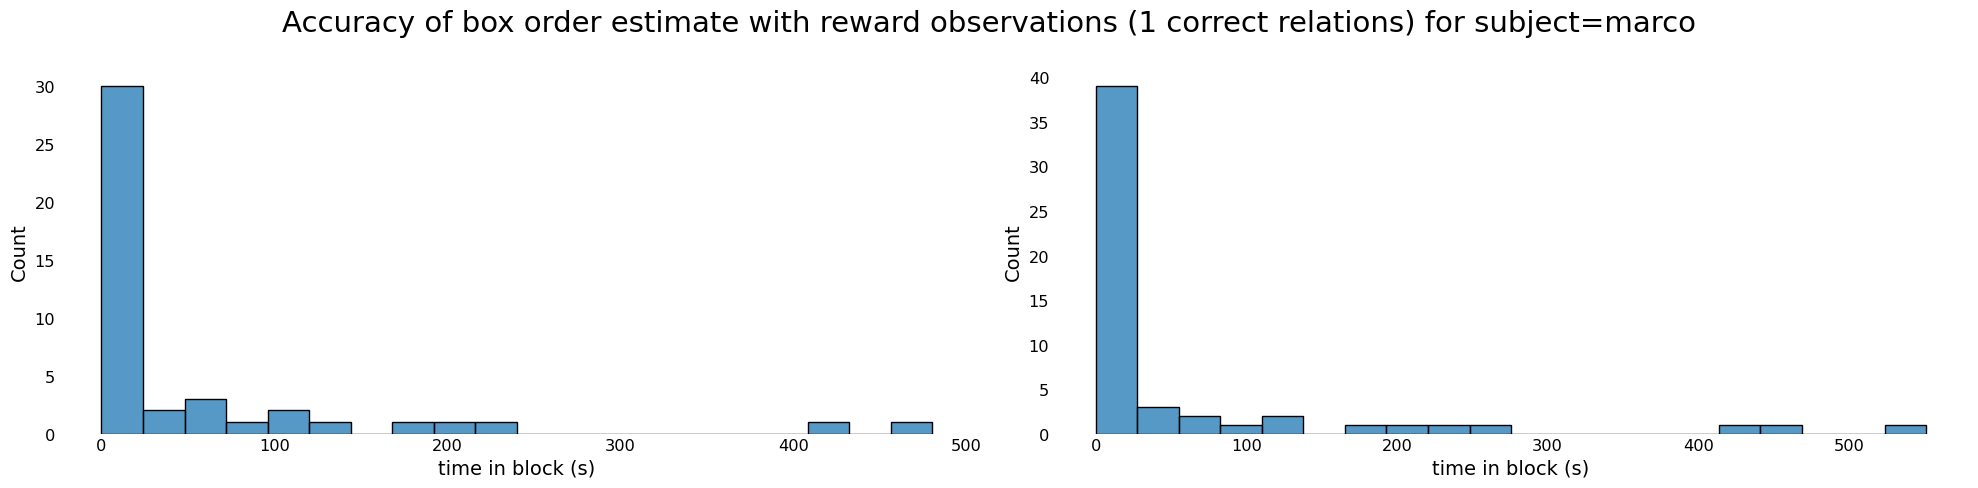

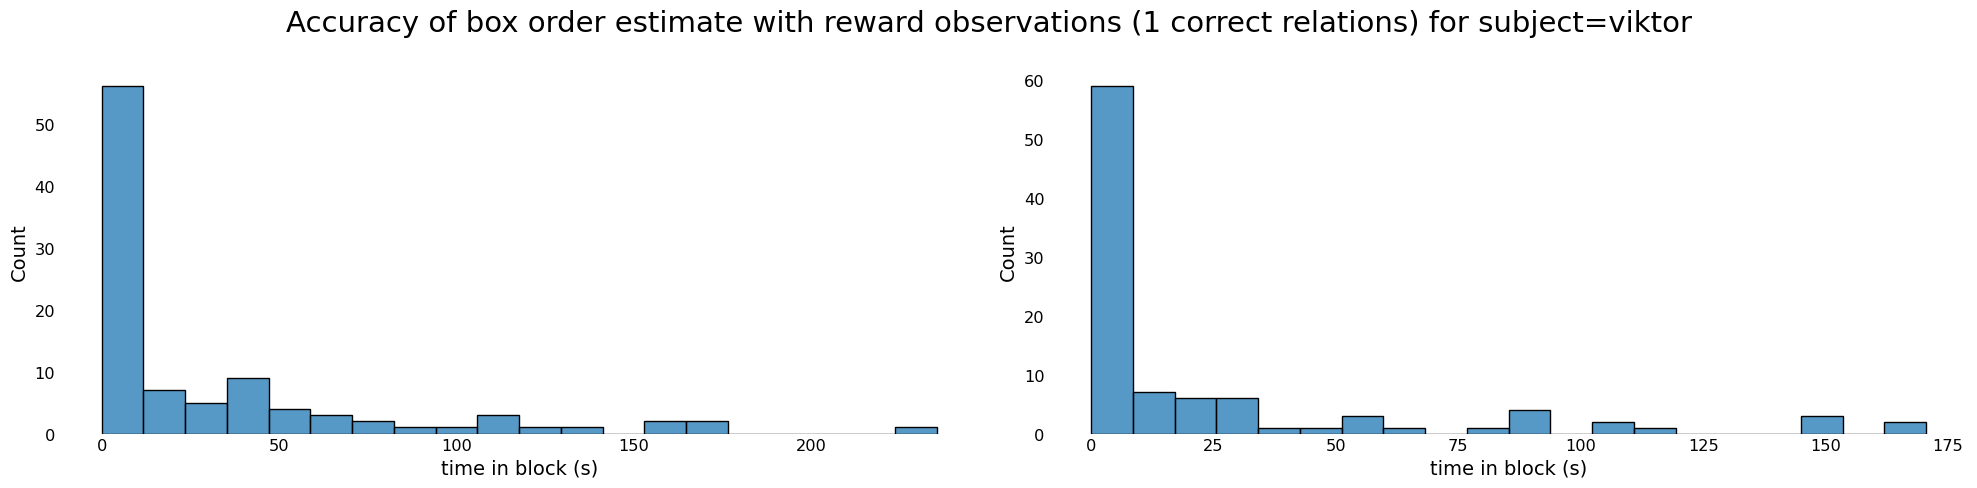

In [37]:
threshold = 0.8
n_correct = 1
threshold_met_times, _ = dataset.process_blocks(compute_when_accuracy_threshold_met, beliefs = perm_beliefs, n_correct = n_correct, n_samples = 500, n_threshold_pts = 10)
plotter.plot_conditions_by_subject(
    plotter.plot_when_accuracy_threshold_met, 
    when_accuracy_threshold_met = threshold_met_times,
    col_condition = 'stimulus reliability',
    fig_title=f'Accuracy of box order estimate with reward observations ({n_correct} correct relations)' 
);

# Joint beliefs schedule and reward

In [3]:
# joint posterior
from foraging.models.distribution import Permutation2SchedulesWrapper

_belief_update = ExactBayesianUpdateOnProbabilities(PermutationLikelihood())
def belief_update(x, y):
    p = _belief_update(x, y)
    return Permutation2SchedulesWrapper(p.support, p.representation)

def posterior_maker(dataset, block_key, block) -> Posterior:
    block = block.reset_index()
    shape = block["shape"].iloc[0]
    schedules = sorted(block["assigned schedules"].iloc[0])
    perms = list(permutations(schedules))
    uniform = 1 / len(perms) * np.ones(len(perms))
    prior = Permutation2SchedulesWrapper(
        support= [PossibleSchedules(schedule = x, shape = shape) for x in perms],
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return Posterior(
        new_key, update = belief_update, prior=prior
    )

joint_beliefs, _ = dataset.process_blocks(compute_joint_schedule_reward_posterior, posterior_maker = posterior_maker)

In [149]:
# joint posterior DISCRETE TIME
from foraging.models.distribution import Permutation2SchedulesWrapper

_belief_update = ExactBayesianUpdateOnProbabilities(PermutationLikelihood())
def belief_update(x, y):
    p = _belief_update(x, y)
    return Permutation2SchedulesWrapper(p.support, p.representation)

def posterior_maker(dataset, block_key, block) -> Posterior:
    block = block.reset_index()
    shape = block["shape"].iloc[0]
    schedules = sorted(block["assigned schedules"].iloc[0])
    perms = list(permutations(schedules))
    uniform = 1 / len(perms) * np.ones(len(perms))
    prior = Permutation2SchedulesWrapper(
        support= [PossibleSchedules(schedule = x, shape = shape) for x in perms],
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return Posterior(
        new_key, update = belief_update, prior=prior
    )

joint_beliefs, _ = dataset.process_blocks(compute_joint_schedule_reward_posterior_discrete_time, posterior_maker = posterior_maker)

<Axes: >

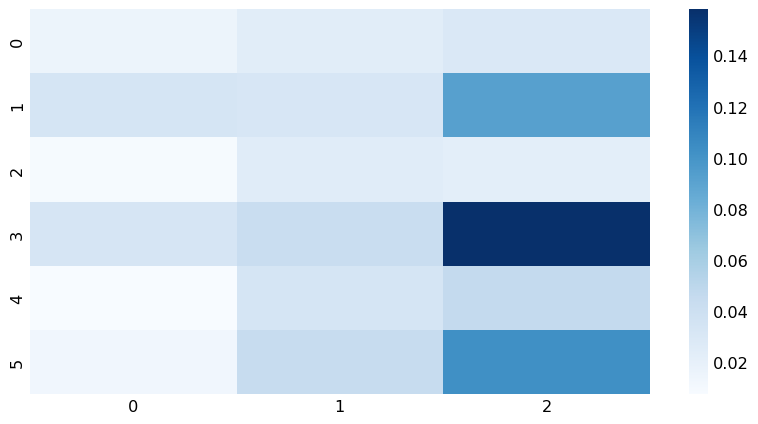

In [163]:
t = list(joint_beliefs[HashableDict(subject="viktor", session=20230120, block=4)].values()) # rows = permutations, columns = physical boxes
sns.heatmap(t[97], cmap = "Blues")

<Axes: >

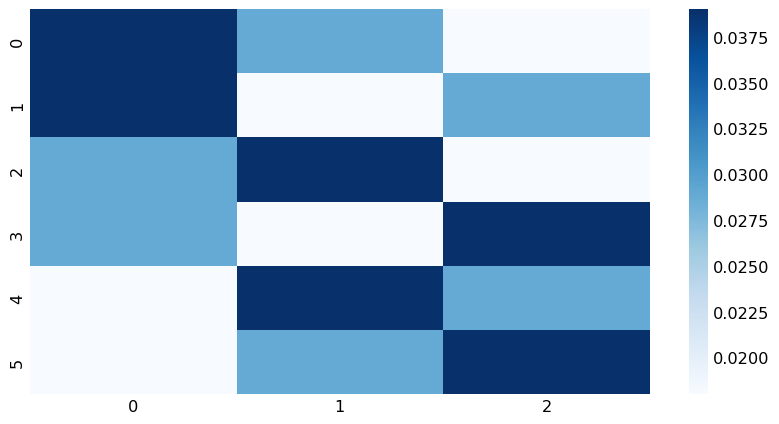

In [151]:
t = list(joint_beliefs[HashableDict(subject="viktor", session=20230120, block=4)].values()) # rows = permutations, columns = physical boxes
sns.heatmap(t[4], cmap = "Blues")

# Model fitting

Split data into train and eval blocks

In [206]:
import random

subj = "marco"
reliability = "high"

# Filter once, then split by block_id to keep Experiment semantics clean.
conds = {"subject": subj, "stimulus reliability": reliability}
dataset_sub = dataset.filter(conds=conds)

# Sample blocks by block_id (block_id is an index level on Experiment.df).
block_ids = list(dataset_sub.get_unique("block_id"))
frac_eval = 0.3
rng = random.Random(0)  # reproducible split; change seed if desired
n_eval_blocks = max(1, int(frac_eval * len(block_ids)))
eval_block_ids = set(rng.sample(block_ids, n_eval_blocks))
train_block_ids = [bid for bid in block_ids if bid not in eval_block_ids]

# Two Experiments with the same API as dataset
train_dataset = dataset_sub.filter({"block_id": train_block_ids})
eval_dataset = dataset_sub.filter({"block_id": list(eval_block_ids)})

print(
    f"train blocks: {len(train_dataset.get_unique('block_id'))}, "
    f"eval blocks: {len(eval_dataset.get_unique('block_id'))}"
)

train blocks: 38, eval blocks: 16


In [210]:
perm = True
mdl_name = f"belief_based_model_{subj}_{reliability}_perm=true" if perm else f"belief_based_model_{subj}_{reliability}_perm=false"
model = fit_policy_to_predict_future_behavior_v2(train_dataset, joint_beliefs, conds = conds, split_frac = [0.8, 0.2], tensorboard_dir = f"tensorboard/{mdl_name}", n_epochs = 1000, patience = 20, permute_labels = perm)

# save model
os.makedirs("session_vars", exist_ok=True)
torch.save(model, f"session_vars/{mdl_name}.pth")

2026-03-05 18:49:57,146 - foraging.utils.belief - INFO - Box label balance (push actions only): counts=[2718, 2826, 2992], fracs=[0.3184, 0.3311, 0.3505]
2026-03-05 18:49:57,150 - foraging.utils.belief - INFO - Permuted action labels using seed 42. 
2026-03-05 18:49:57,159 - foraging.utils.belief - INFO - Training on device: cuda
2026-03-05 18:49:58,780 - foraging.utils.belief - INFO - Epoch 0/1000: Train Loss=0.6996, Test Loss=0.6776, Test Acc=0.8174
2026-03-05 18:50:13,072 - foraging.utils.belief - INFO - Epoch 10/1000: Train Loss=0.6665, Test Loss=0.6764, Test Acc=0.8174
2026-03-05 18:50:25,808 - foraging.utils.belief - INFO - Epoch 20/1000: Train Loss=0.6650, Test Loss=0.6769, Test Acc=0.8174
2026-03-05 18:50:40,078 - foraging.utils.belief - INFO - Epoch 30/1000: Train Loss=0.6638, Test Loss=0.6776, Test Acc=0.8174
2026-03-05 18:50:42,961 - foraging.utils.belief - INFO - Early stopping at epoch 32
2026-03-05 18:50:42,963 - foraging.utils.belief - INFO - Training complete. Best test

In [208]:
mdl_name = f"belief_based_model_{subj}_{reliability}"
model = torch.load(f"session_vars/{mdl_name}_perm=false.pth", weights_only = False)
model_perm = torch.load(f"session_vars/{mdl_name}_perm=true.pth", weights_only = False)

(-2.0, 2.0)

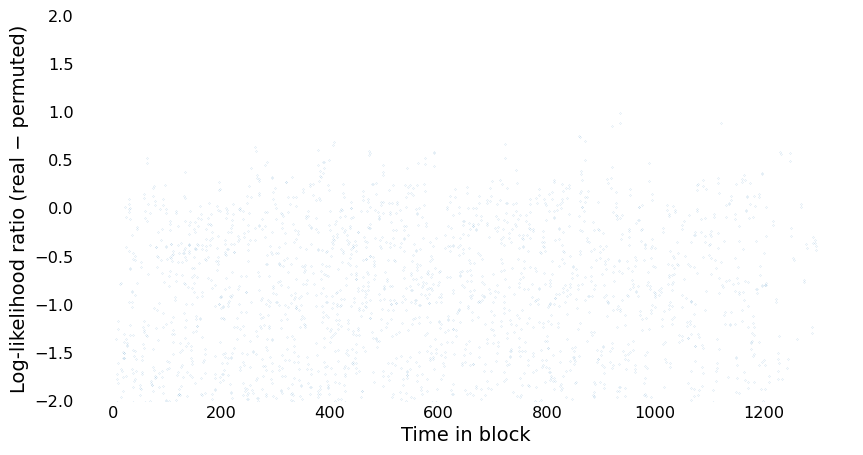

In [209]:
# plotter.plot_conditions_by_subject(
#     plotter.plot_policy_fit_across_block, 
#     col_condition = 'stimulus reliability',
#     model = model,
#     beliefs = joint_beliefs
# );
plotter = BeliefPlotter(joint_beliefs, eval_dataset, AngelakiPlottingConfig().to_dict())
# ax = plotter.plot_policy_fit_across_block(model = model, beliefs = joint_beliefs, show_traces=True, show_average = False, conds = conds, x = "push times")
ax = plotter.plot_belief_based_policy_llr_scatterplot(model_real = model, model_perm = model_perm, beliefs = joint_beliefs, conds = conds, relative_time = False);
ax.set_ylim(-2,2)

### Accuracy by class labels

(<Axes: xlabel='True class', ylabel='Accuracy'>,
    class class_label      n  correct  accuracy
 0      0      push_0   7040     3776  0.536364
 1      1      push_1   8480     5780  0.681604
 2      2      push_2  11572     8405  0.726322
 3      3        wait  19613    10510  0.535869)

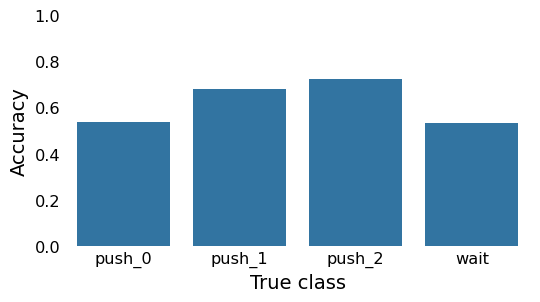

In [205]:
# todo: plot the prediction accuracy per action label (wait, push 1, push 2, ..., push n_boxes)
plotter.plot_belief_policy_accuracy_by_class(model = model, beliefs = joint_beliefs, conds = conds)


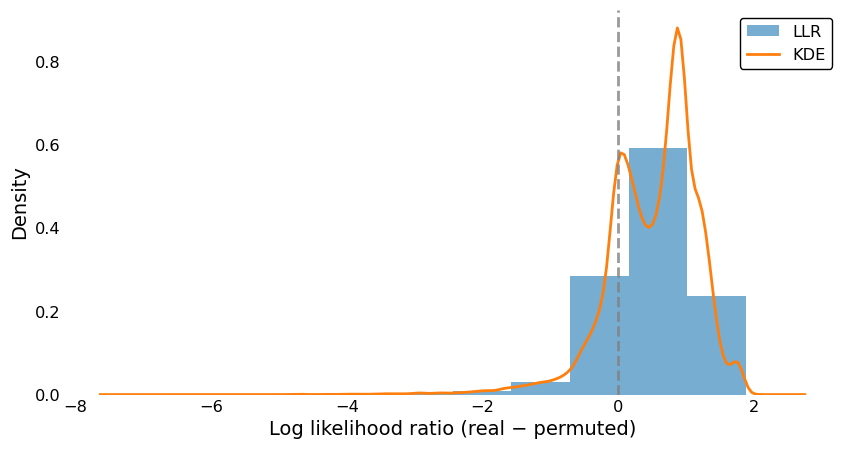

In [188]:
# plotter.plot_conditions_by_subject(
#     plotter.plot_policy_fit_across_block, 
#     col_condition = 'stimulus reliability',
#     model = model,
#     beliefs = joint_beliefs
# );

plotter = BeliefPlotter(joint_beliefs, eval_dataset, AngelakiPlottingConfig().to_dict())
ax, llr_belief = plotter.plot_belief_based_policy_llr_distribution(model_real = model, model_perm = model_perm, beliefs = joint_beliefs, conds = conds)

Text(0.5, 0, 'Log likelihood ratio (real − permuted)')

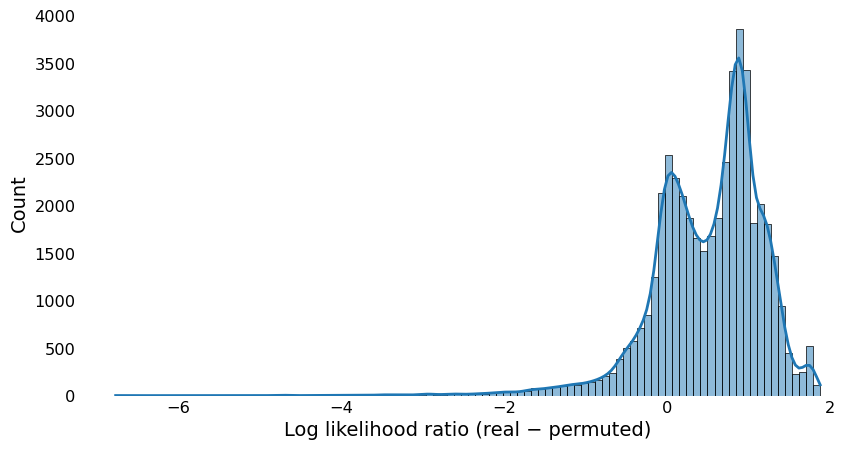

In [189]:
import seaborn as sns
ax = sns.histplot(llr_belief, bins = 100, kde = True)
ax.set_xlabel("Log likelihood ratio (real − permuted)")
# convenience load and save of variables

## Recent history model

In [128]:
k = 100
perm = False
mdl_name = f"recent_history_model_{subj}_{reliability}_k={k}_perm=true" if perm else f"recent_history_model_{subj}_{reliability}_k={k}_perm=false"
model = fit_recent_history_to_predict_future_behavior(train_dataset, conds = conds, split_frac = [0.8, 0.2], tensorboard_dir = f"tensorboard/{mdl_name}", n_epochs = 1000, patience = 20, permute_labels = perm, k_history = k)

# save model
os.makedirs("session_vars", exist_ok=True)
torch.save(model, f"session_vars/{mdl_name}.pth")

2026-03-02 17:48:29,179 - foraging.utils.belief - INFO - Formatted 8035 samples with input_dim=503, n_boxes=3, n_actions=4, bin_size=1.0
2026-03-02 17:48:29,197 - foraging.utils.belief - INFO - Training on device: cuda
2026-03-02 17:48:29,497 - foraging.utils.belief - INFO - Epoch 0/1000: Train Loss=0.6351, Test Loss=0.5948, Test Acc=0.8475
2026-03-02 17:48:31,823 - foraging.utils.belief - INFO - Epoch 10/1000: Train Loss=0.5337, Test Loss=0.6102, Test Acc=0.8475
2026-03-02 17:48:34,107 - foraging.utils.belief - INFO - Epoch 20/1000: Train Loss=0.4984, Test Loss=0.6535, Test Acc=0.8475
2026-03-02 17:48:32,876 - foraging.utils.belief - INFO - Early stopping at epoch 21
2026-03-02 17:48:32,877 - foraging.utils.belief - INFO - Training complete. Best test loss: 0.5910


In [190]:
k = 2
mdl_name = f"recent_history_model_{subj}_{reliability}_k={k}"
model = torch.load(f"session_vars/{mdl_name}_perm=false.pth", weights_only = False)
model_perm = torch.load(f"session_vars/{mdl_name}_perm=true.pth", weights_only = False)

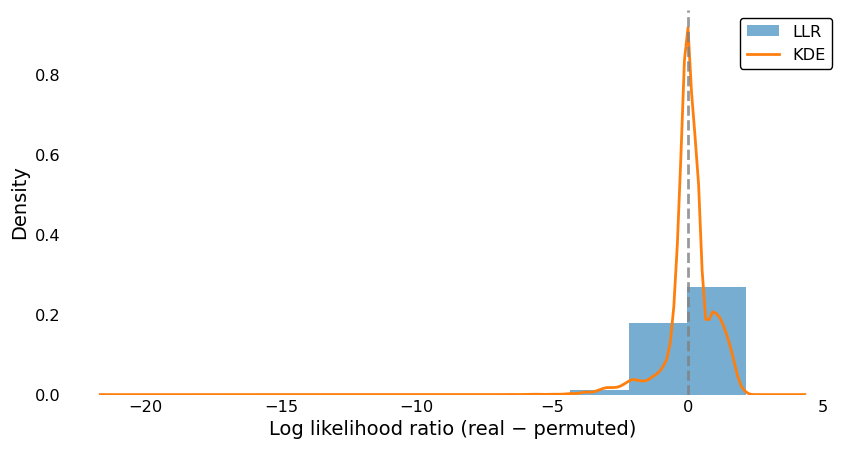

In [191]:
plotter = BeliefPlotter(joint_beliefs, eval_dataset, AngelakiPlottingConfig().to_dict())
ax, llr_recent_1 = plotter.plot_recent_history_llr_distribution(model_real = model, model_perm = model_perm, k_history = k, conds = conds)

Text(0.5, 0, 'Log likelihood ratio (real − permuted)')

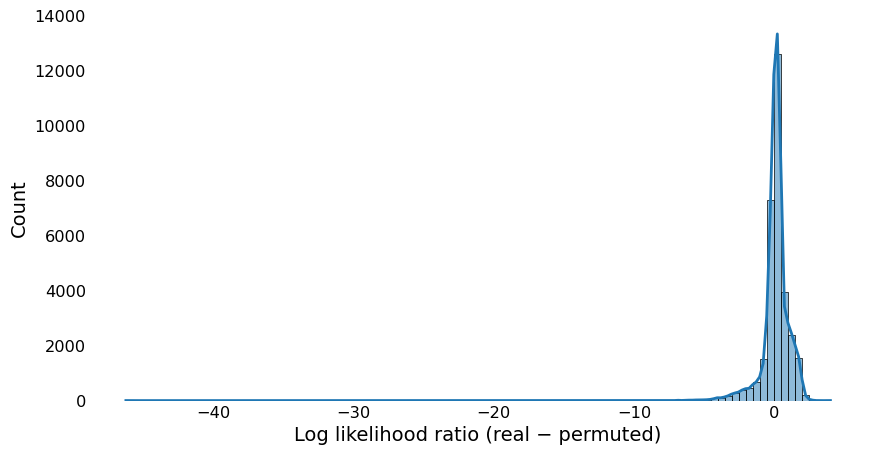

In [ ]:
import seaborn as sns
ax = sns.histplot(llr_recent_1, bins = 100, kde = True)
ax.set_xlabel("Log likelihood ratio (real − permuted)")
# convenience load and save of variables

In [192]:
k = 20
mdl_name = f"recent_history_model_{subj}_{reliability}_k={k}"
model = torch.load(f"session_vars/{mdl_name}_perm=false.pth", weights_only = False)
model_perm = torch.load(f"session_vars/{mdl_name}_perm=true.pth", weights_only = False)

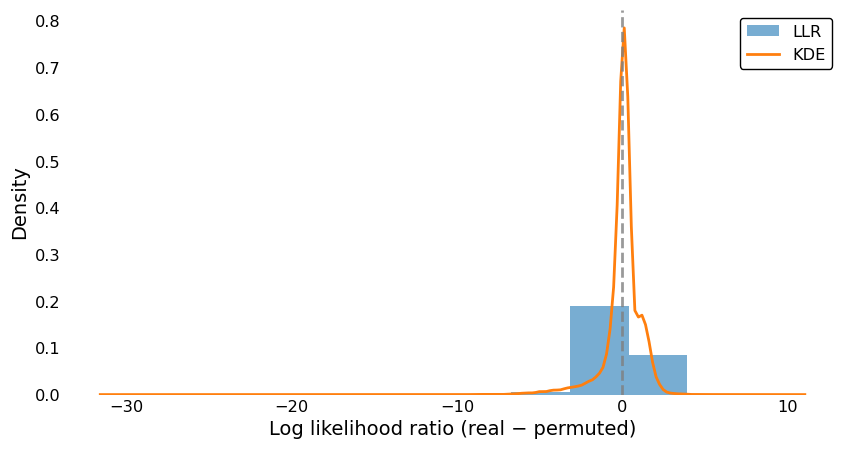

In [193]:
plotter = BeliefPlotter(joint_beliefs, eval_dataset, AngelakiPlottingConfig().to_dict())
ax, llr_recent_2 = plotter.plot_recent_history_llr_distribution(model_real = model, model_perm = model_perm, k_history = k, conds = conds);

In [194]:
k = 100
mdl_name = f"recent_history_model_{subj}_{reliability}_k={k}"
model = torch.load(f"session_vars/{mdl_name}_perm=false.pth", weights_only = False)
model_perm = torch.load(f"session_vars/{mdl_name}_perm=true.pth", weights_only = False)

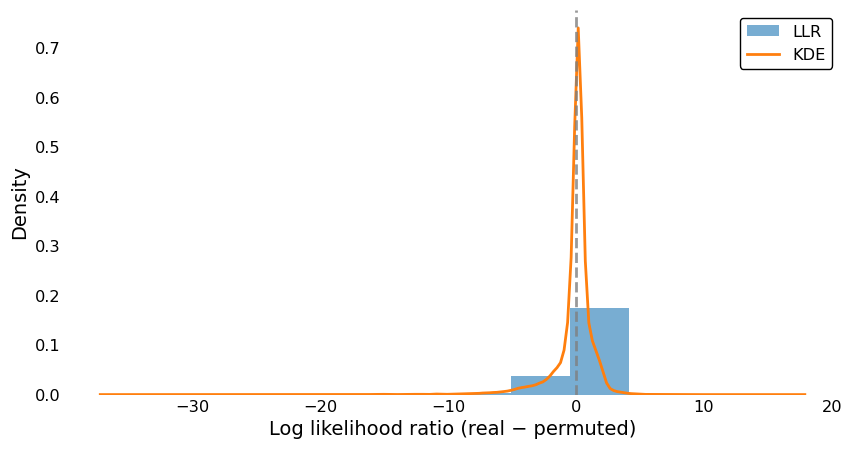

In [195]:
plotter = BeliefPlotter(joint_beliefs, eval_dataset, AngelakiPlottingConfig().to_dict())
ax, llr_recent_3 = plotter.plot_recent_history_llr_distribution(model_real = model, model_perm = model_perm, k_history = k, conds = conds);

# Combining belief-based and history-based on one plot

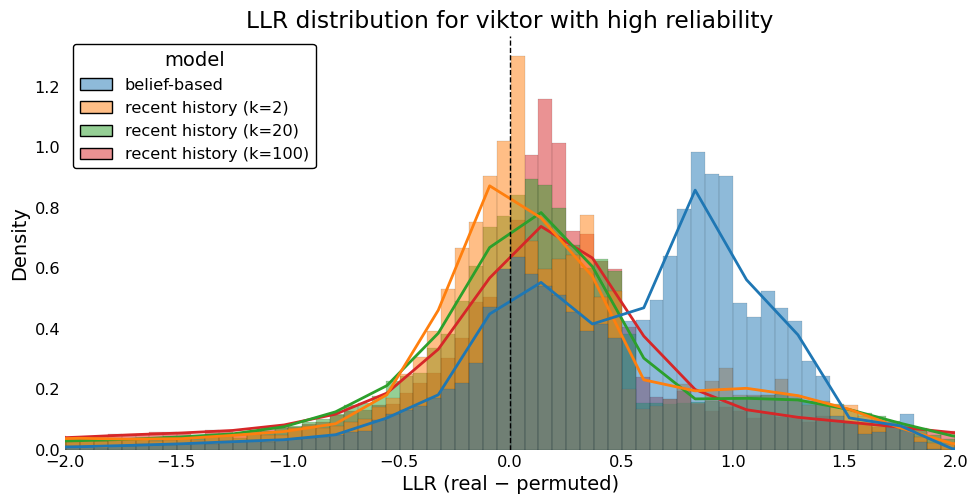

In [196]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "llr": pd.concat([
        pd.Series(llr_belief, name="llr"),
        pd.Series(llr_recent_1, name="llr"),
        pd.Series(llr_recent_2, name="llr"),
        pd.Series(llr_recent_3, name="llr"),
    ], ignore_index=True),
    "model": (["belief-based"] * len(llr_belief)
              + ["recent history (k=2)"] * len(llr_recent_1)
              + ["recent history (k=20)"] * len(llr_recent_2)
              + ["recent history (k=100)"] * len(llr_recent_3)),
})

# plt.figure(figsize=(7, 4))
sns.histplot(
    data=df,
    x="llr",
    hue="model",
    kde = True,
    stat="density",         # or "count"
    common_norm=False,      # keep each distribution normalized separately
    # element="step",
    # fill=False,
    # bins=40,
    # alpha=0.8,
)
plt.axvline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("LLR (real − permuted)")
plt.xlim(-2, 2)
plt.tight_layout()
plt.title(f"LLR distribution for {subj} with {reliability} reliability")
plt.show()

In [ ]:
#todo: potentially flag blocks where recent history models have LLR > 2. note that this need not be interesting pushes, since the histogram does not pair LLRs by pushes e.g. LLR > 2 for a recent history model might correspond to a push that has LLR = 0.5 by belief model
